<a href="https://colab.research.google.com/github/NataZBluszczu/python-visualizations/blob/main/matplotlib_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Biblioteka Matplotlib

Matplotlib to kompleksowa biblioteka służąca to tworzenia statycznych i animowanych wizualizacji w Pythonie. Umożliwia dostosowanie wykresów pod dowolne wymagania i zapisanie ich w wysokiej jakości.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.ticker as ticker
import matplotlib.animation as animation

plt.style.use('default')

MY_COLORS = ["#DD9296", "#9AD1D4", "#62C370", "#CC3363", "#09BC8A"]

In [ ]:
!pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "dataset.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "maharshipandya/-spotify-tracks-dataset",
  file_path,
)

print("Załadowano pomyślnie!")
df.head()

/tmp/ipykernel_7248/691891707.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.
Załadowano pomyślnie!


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


--------------------
### Histogram

Histogram przedstawia rozłożenie różnych wartości w danej kategorii. Jego wygląd jest podobny do wykresu kolumnowego, jednak jego zastosowanie jest zupełnie inne i wykresy te nie powinny być ze sobą mylone.

##### ⭐ Zadanie 1:

Przygotuj histogram (`hist`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zapoznaj się z parametrami `bins` i `range` oraz dobierz dla nich takie wartości, które wg. Ciebie najlepiej wizualizują dane. Dodatkowo, zapoznaj się z parametrem `density`. Zadbaj o czytelność wykresu (tytuł wykresu oraz podpisy osi).

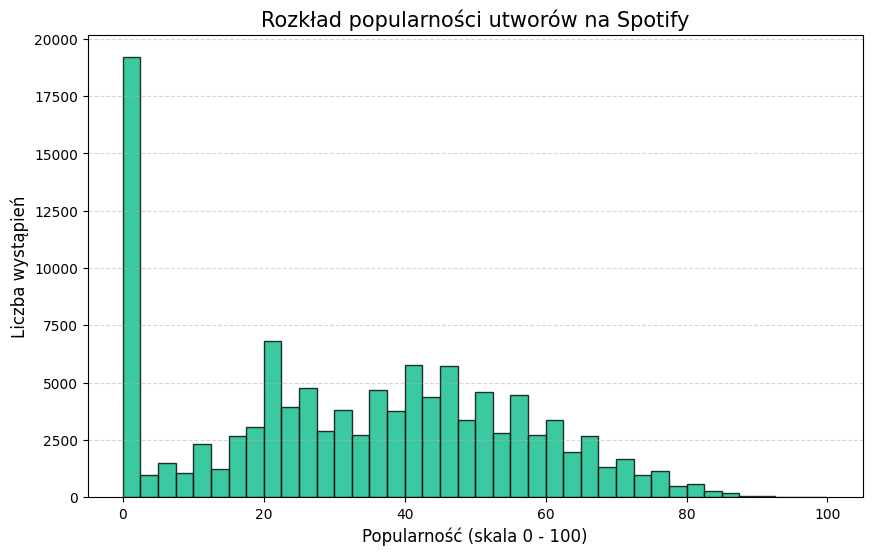

In [ ]:
# bins - liczba słupków (przedziałów popularności)
# range - zakres wartości, które chcemy zobaczyć na wykresie
# density - czy normalizować do gęstości (procentów) czy pokazać surowe liczby

data = df['popularity']

plt.figure(figsize=(10, 6))


plt.hist(data,
         bins=40,
         range=(0, 100),
         density=False,
         color=MY_COLORS[4],
         alpha=0.8,
         edgecolor='black')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.title('Rozkład popularności utworów na Spotify', fontsize=15)
plt.xlabel('Popularność (skala 0 - 100)', fontsize=12)
plt.ylabel('Liczba wystąpień', fontsize=12)

plt.show()

##### ⭐ Zadanie 2:

Przygotuj dwuwymiarowy histogram (`hist2d`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi oraz legenda).

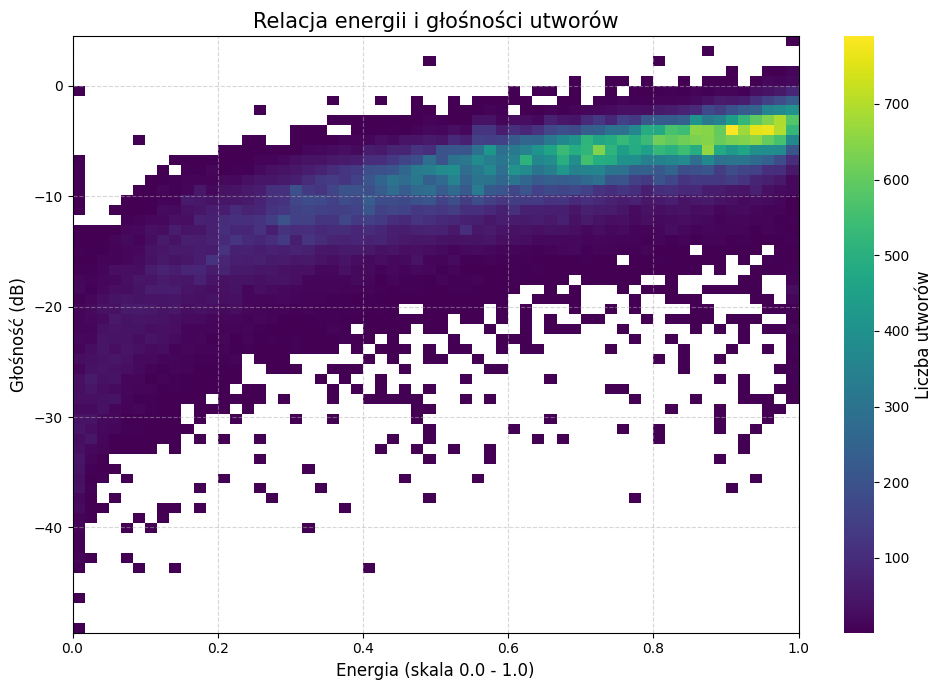

In [ ]:
# Dwuwymiarowy histogram (histogram 2D) - pokazuje zagęszczenie danych w dwóch wymiarach jednocześnie
# bins - liczba koszyków w pionie i poziomie (np. bins=[50, 50] oznacza 50 koszyków dla każdej osi)
plt.figure(figsize=(10, 7), facecolor='white')
ax = plt.axes()

h2d = plt.hist2d(df['energy'], df['loudness'],
                 bins=60,
                 cmap='viridis',
                 cmin=1)

cb = plt.colorbar(h2d[3])
cb.set_label('Liczba utworów', fontsize=12)
cb.outline.set_visible(False)
cb.ax.yaxis.set_tick_params(color='black', labelcolor='black')

plt.title('Relacja energii i głośności utworów', fontsize=15)
plt.xlabel('Energia (skala 0.0 - 1.0)', fontsize=12)
plt.ylabel('Głośność (dB)', fontsize=12)

plt.grid(linestyle='--', alpha=0.5)

plt.tight_layout() # Automatycznie dostosowuje rozmieszczenie podwykresów, aby uniknąć nakładania się tytułów czy etykiet
plt.show()

##### ⭐ Zadanie 3:

Przygotuj dwuwymiarowy histogram z heksagonami (`hexbin`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zapoznaj się z parametrem `gridsize` oraz dobierz dla niego taką wartość, która wg. Ciebie najlepiej wizualizuje dane. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi oraz legenda).

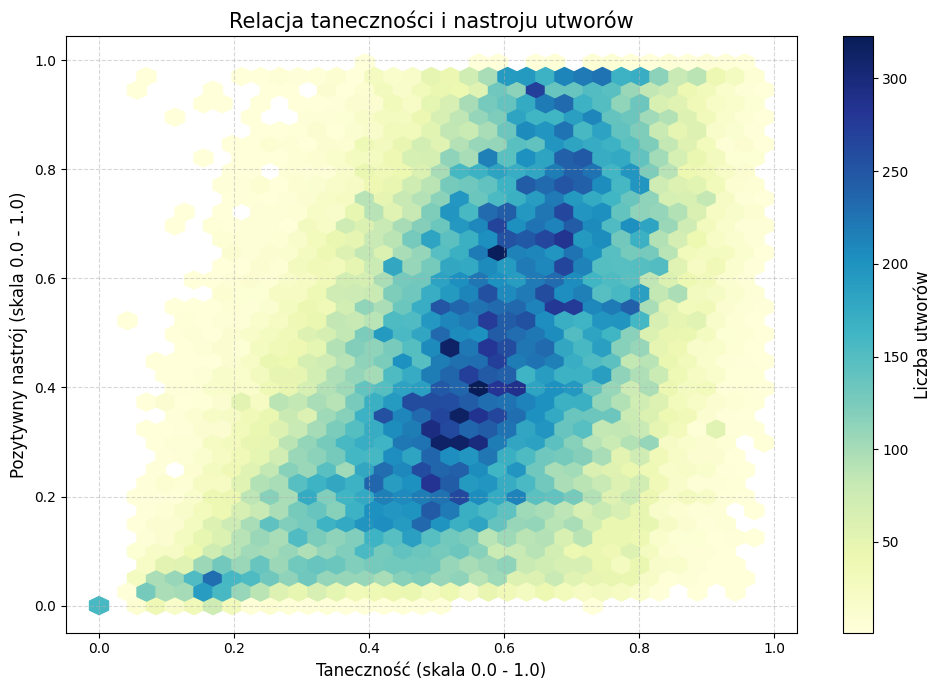

In [ ]:
plt.figure(figsize=(10, 7), facecolor='white')
ax = plt.axes()

hb = plt.hexbin(df['danceability'], df['valence'],
                gridsize=35,
                cmap='YlGnBu',
                mincnt=1)

cb = plt.colorbar(hb)
cb.set_label('Liczba utworów', fontsize=12)

plt.title('Relacja taneczności i nastroju utworów', fontsize=15)
plt.xlabel('Taneczność (skala 0.0 - 1.0)', fontsize=12)
plt.ylabel('Pozytywny nastrój (skala 0.0 - 1.0)', fontsize=12)

plt.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

-------------------
### Wykres słupkowy i kolumnowy (skumulowany)

Wykres kolumnowy i wykres słupkowy pokazuje jawne wartości dla pojedynczej lub dla wielu serii danych. Oś z wartościami liczbowymi powinna zaczynać się od 0, żeby uniknąć ukrytego przeskoku, który może dawać mylne złudzenie. Podpisy danych muszą być czytelne, zatem często są one umieszczone prostopadle do kolumn / słupków. <br/><br/>
Wykres kolumnowy lub słupkowy skumulowany dodatkowo rozróżnia kolejne serie danych, które są składnikami sumy końcowej dla wyświetlanych wartości. Serie danych najczęściej są rozróżniane kolorem, zatem do ich zrozumienia potrzebna jest legenda.

##### ⭐ Zadanie 4:

Przygotuj wykres kolumnowy (`bar`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zapoznaj się z parametrem `tick_label` i ustawieniami `xticks` oraz dobierz dla nich takie wartości, które wg. Ciebie najlepiej wizualizują dane. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi oraz podpis dla każdej kolumny).

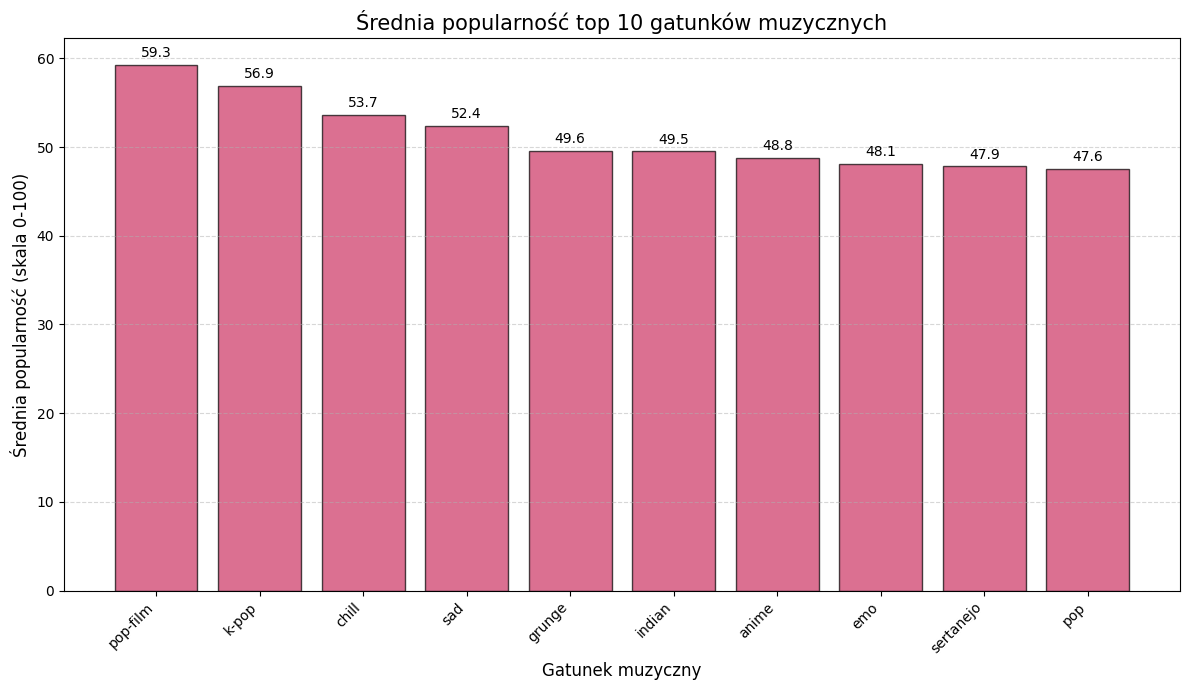

In [ ]:
# tick_label pozwala nam przypisać nazwy kategorii do słupków
# xticks - pozycje słupków, które ustawiamy na podstawie liczby kategorii

genre_pop = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)
genres = genre_pop.index.tolist()
popularity_values = genre_pop.values.tolist()

plt.figure(figsize=(12, 7), facecolor='white')


bars = plt.bar(range(len(genres)), popularity_values,
               tick_label=genres,
               color=MY_COLORS[3],
               edgecolor='black',
               alpha=0.7)

plt.xticks(rotation=45, ha='right')

plt.title('Średnia popularność top 10 gatunków muzycznych', fontsize=15)
plt.xlabel('Gatunek muzyczny', fontsize=12)
plt.ylabel('Średnia popularność (skala 0-100)', fontsize=12)

plt.grid(linestyle='--', alpha=0.5, axis='y')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, round(yval, 1),
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

##### ⭐ Zadanie 5:

Przygotuj wykres słupkowy (`barh`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zapoznaj się z funkcją `gca()` oraz ustawieniami `set_yticks` i `set_yticklabels`. Wykorzystaj je, żeby wyeliminować niestandardowe odstępy pomiędzy danymi. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi oraz podpis dla każdego słupka).

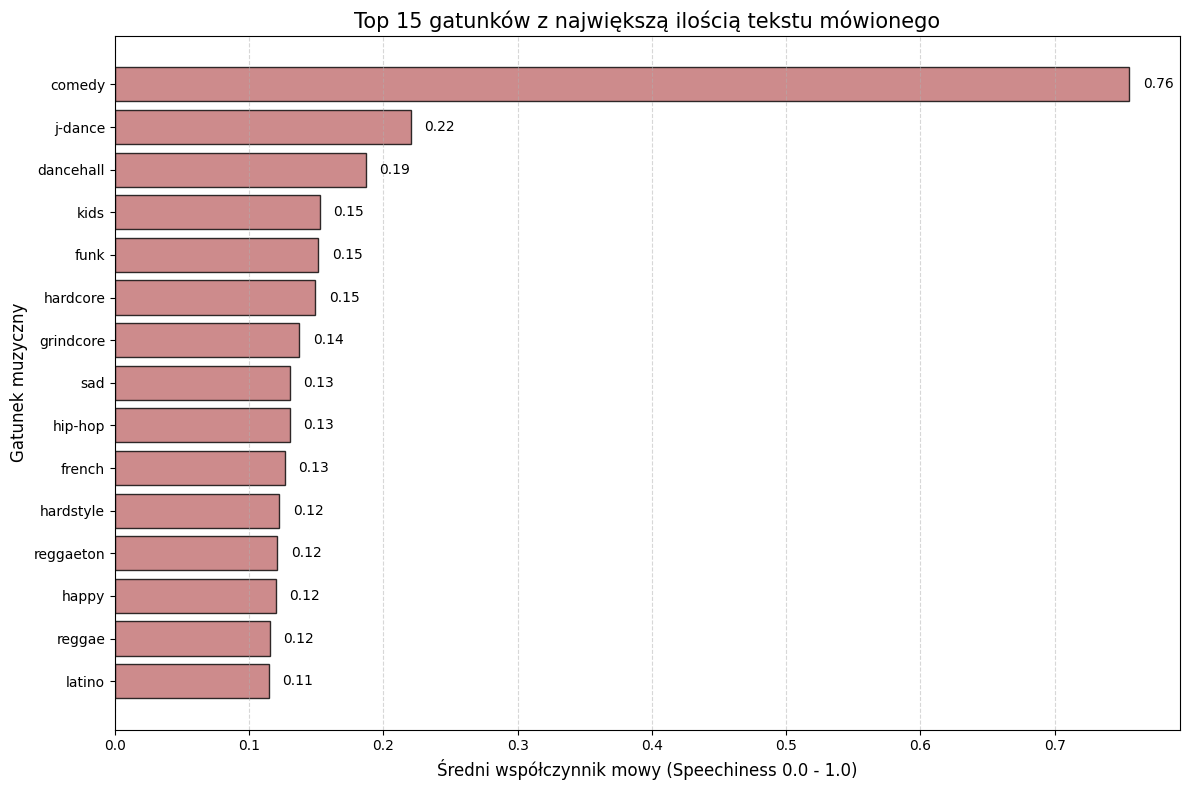

In [ ]:
# gca() - Get Current Axes, pozwala nam na precyzyjną kontrolę nad osiami i etykietami
# set_yticks() i set_yticklabels() - pozwalają nam ustawić dokładnie, gdzie mają być etykiety na osi Y i jakie mają mieć nazwy

BAR_COLOR = "#C16E70"

speech_by_genre = df.groupby('track_genre')['speechiness'].mean().sort_values(ascending=True).tail(15)
genres = speech_by_genre.index.tolist()
values = speech_by_genre.values.tolist()

plt.figure(figsize=(12, 8))

y_pos = range(len(genres))
bars = plt.barh(y_pos, values, color=BAR_COLOR, edgecolor="black", alpha=0.8)

ax = plt.gca()
ax.set_yticks(y_pos)
ax.set_yticklabels(genres)

for i, v in enumerate(values):
    plt.text(v + 0.01, i, f"{v:.2f}", va='center', fontsize=10)

plt.title('Top 15 gatunków z największą ilością tekstu mówionego', fontsize=15)
plt.xlabel('Średni współczynnik mowy (Speechiness 0.0 - 1.0)', fontsize=12)
plt.ylabel('Gatunek muzyczny', fontsize=12)

plt.grid(linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()

##### ⭐ Zadanie 6:

Przygotuj wykres kolumnowy (`bar`) opierając się na danych, które sam wybierzesz w sensowny sposób. Uwzględnij co najmniej 3 serie danych. Zapoznaj się z parametrem `width` oraz dobierz dla niego właściwą wartość mając na uwadze wizualizację określonej liczby serii danych. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi i podpis dla każdej grupy kolumn oraz legenda).

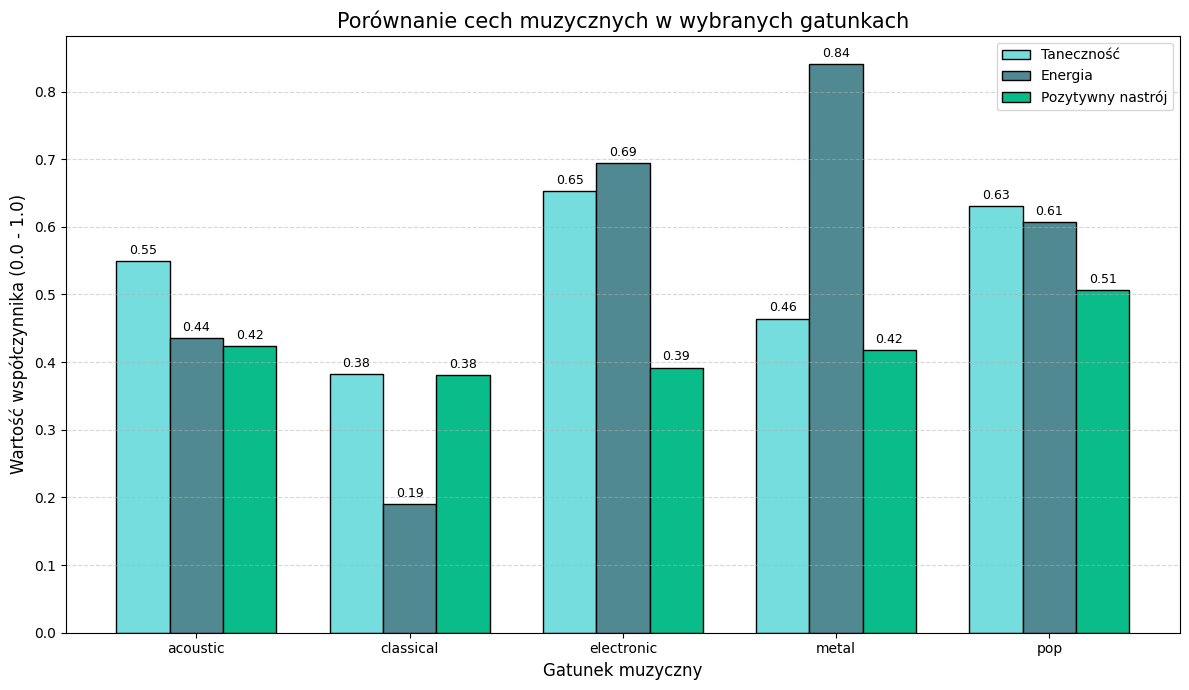

In [ ]:
COLOR1, COLOR2, COLOR3 = "#75DDDD", "#508991", "#09BC8A"

target_genres = ['pop', 'metal', 'classical', 'acoustic', 'electronic']
stats = df[df['track_genre'].isin(target_genres)].groupby('track_genre')[['danceability', 'energy', 'valence']].mean()

genres = stats.index
dance, energy, valence = stats['danceability'], stats['energy'], stats['valence']

x = np.arange(len(genres))
width = 0.25

plt.figure(figsize=(12, 7))
ax = plt.gca()

ax.bar(x - width, dance, width, label='Taneczność', color=COLOR1, edgecolor='black')
ax.bar(x, energy, width, label='Energia', color=COLOR2, edgecolor='black')
ax.bar(x + width, valence, width, label='Pozytywny nastrój', color=COLOR3, edgecolor='black')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.title('Porównanie cech muzycznych w wybranych gatunkach', fontsize=15)
plt.xlabel('Gatunek muzyczny', fontsize=12)
plt.ylabel('Wartość współczynnika (0.0 - 1.0)', fontsize=12)

plt.xticks(x, genres)
plt.legend()
plt.grid(linestyle='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.show()

##### ⭐ Zadanie 7:

Przygotuj wykres kolumnowy skumulowany (`bar`) opierając się na danych, które sam wybierzesz w sensowny sposób. Uwzględnij co najmniej 3 serie danych. Zapoznaj się z parametrem `bottom` oraz dobierz dla niego właściwą wartość mając na uwadze wizualizację określonej liczby serii danych jako składników sumy. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi i podpis dla każdej kolumn oraz legenda).

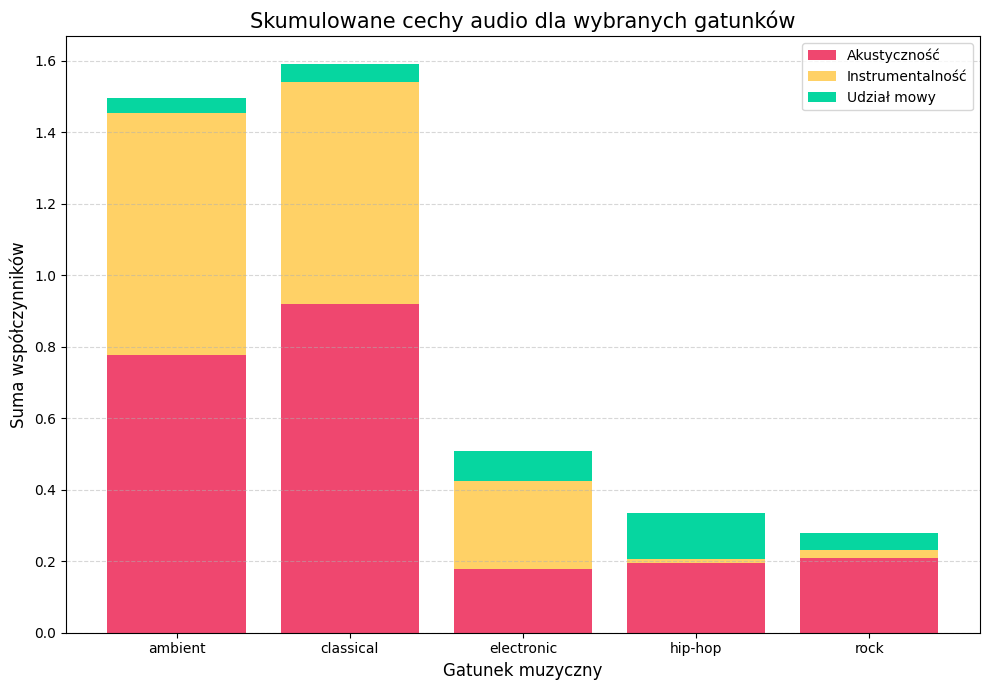

In [ ]:
# bottom - pozwala nam "układać" słupki jeden na drugim, tworząc efekt skumulowany

COLOR1, COLOR2, COLOR3 = "#ef476f", "#ffd166", "#06d6a0"

target_genres = ['ambient', 'classical', 'electronic', 'hip-hop', 'rock']
stats = df[df['track_genre'].isin(target_genres)].groupby('track_genre')[['acousticness', 'instrumentalness', 'speechiness']].mean()

genres = stats.index
s1 = stats['acousticness'].values
s2 = stats['instrumentalness'].values
s3 = stats['speechiness'].values

plt.figure(figsize=(10, 7))
ax = plt.gca()

ax.bar(genres, s1, color=COLOR1, label='Akustyczność')
ax.bar(genres, s2, bottom=s1, color=COLOR2, label='Instrumentalność')
ax.bar(genres, s3, bottom=s1+s2, color=COLOR3, label='Udział mowy')

plt.title('Skumulowane cechy audio dla wybranych gatunków', fontsize=15)
plt.xlabel('Gatunek muzyczny', fontsize=12)
plt.ylabel('Suma współczynników', fontsize=12)

plt.legend()
plt.grid(linestyle='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.show()

-------------------
### Wykres kołowy

Wykres kołowy przedstawia zależność pomiędzy obiektami, które są częścią całości. Każdy wycinek koła reprezentuje część składową obiektu. Dobrym zwyczajem jest umieszczanie wycinków w kolejności rosnącej lub malejącej, a nie losowej.

##### ⭐ Zadanie 8:

Przygotuj wykres kołowy (`pie`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zapoznaj się z parametrami `normalize`, `explode` oraz `autopct`, `pctdistance`, `labels`, `labeldistance` i dobierz dla nich właściwe wartości, które wg. Ciebie najlepiej wizualizują dane. Zadbaj o czytelność wykresu (tytuł wykresu, podpis i wartość procentowa dla każdej części koła).

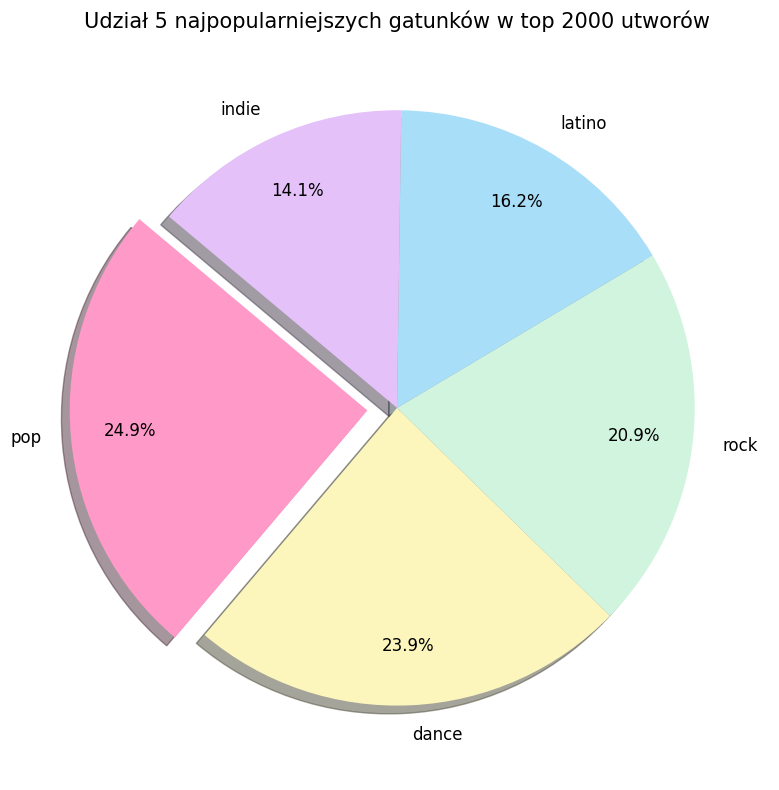

In [ ]:
# normalize=True - sprawia, że wartości zostaną znormalizowane do 100%, co jest ważne dla wykresu kołowego, aby pokazać procentowy udział każdej kategorii
# explode - pozwala nam "wysunąć" wybrany kawałek koła, aby go wyróżnić (np. największy udział)
# autopct - format wyświetlania procentów, np. '%1.1f%%' oznacza 1 miejsce po przecinku i znak procenta
# pctdistance - odległość wartości procentowych od środka koła (np. 0.8 oznacza, że będą wewnątrz koła)
# labels - etykiety kategorii, które będą wyświetlane na wykresie
# labeldistance - odległość etykiet tekstowych od środka koła (np. 1.1 oznacza, że będą na zewnątrz koła)

MY_COLORS = ["#ff99c8", "#fcf6bd", "#d0f4de", "#a9def9", "#e4c1f9"]

top_tracks = df.sort_values(by='popularity', ascending=False).head(2000)
genre_distribution = top_tracks['track_genre'].value_counts().head(5)

labels = genre_distribution.index
sizes = genre_distribution.values

explode = (0.1, 0, 0, 0, 0)

plt.figure(figsize=(10, 8))

plt.pie(sizes,
        normalize=True, # Zapewnienie, że dane zostaną znormalizowane do 100%
        pctdistance=0.8, # Odległość wartości procentowych od środka (wewnątrz koła)
        labels=labels, # Podpisy kategorii
        autopct='%.1f%%', # Format wyświetlania procentów (1 miejsce po przecinku)
        labeldistance=1.1, # Odległość etykiet tekstowych od środka (na zewnątrz koła)
        startangle=140, # Obrót początkowy dla lepszej kompozycji
        explode=explode, # Rozsunięcie (wyróżnienie największego udziału)
        colors=MY_COLORS,
        shadow=True,
        textprops={'fontsize': 12})

plt.title('Udział 5 najpopularniejszych gatunków w top 2000 utworów', fontsize=15)

plt.tight_layout()
plt.show()

##### ⭐ Zadanie 9:

Przygotuj wykres kołowy (`pie`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zastosuj co najmniej 3 serie danych i podziel te informacje na osobne podwykresy (`subplot`) jednego obrazu. Zapoznaj się z obiektami `figure` i `axes`. Zadbaj o czytelność wykresu (tytuł obrazu i każdego wykresu, podpis i wartość procentowa dla każdej części koła).

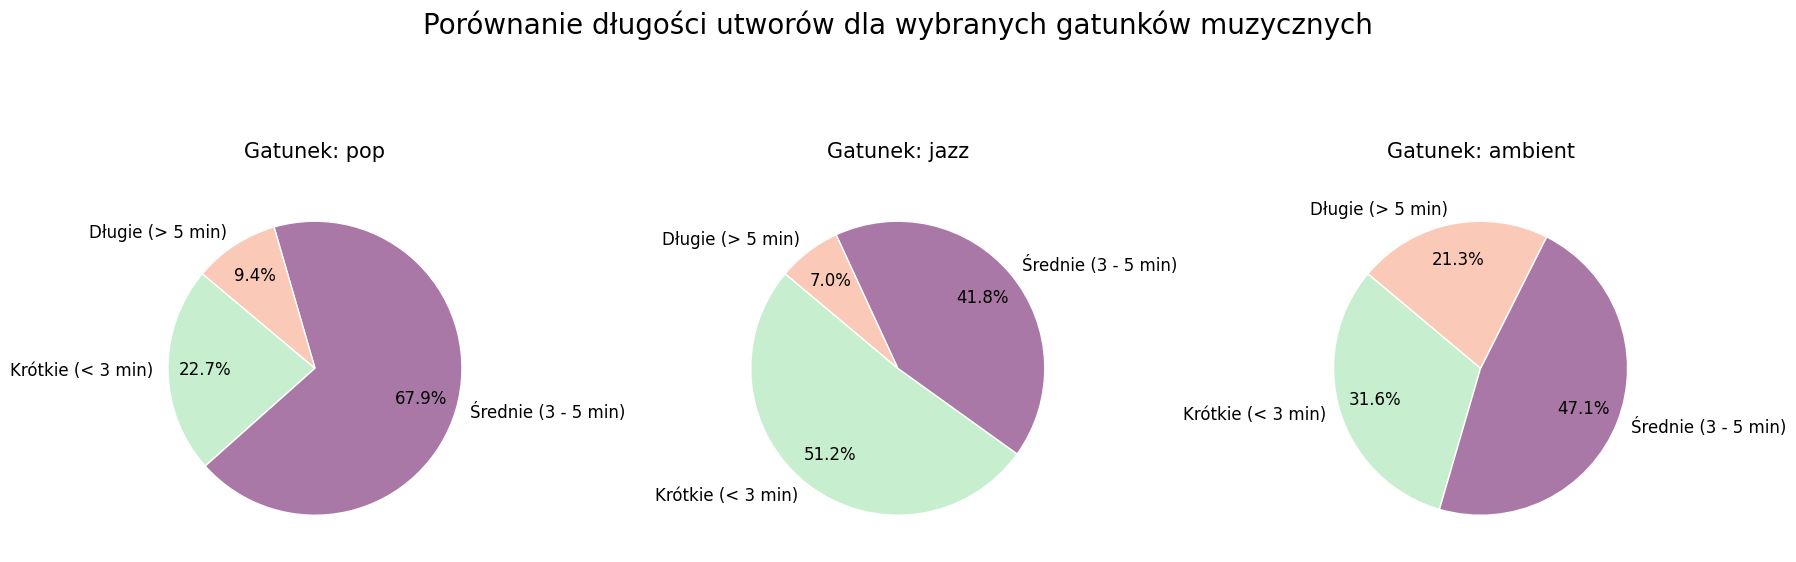

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Przygotowanie danych
df['duration_min'] = df['duration_ms'] / 60000
bins = [0, 3, 5, float('inf')]
labels = ['Krótkie (< 3 min)', 'Średnie (3 - 5 min)', 'Długie (> 5 min)']
df['duration_cat'] = pd.cut(df['duration_min'], bins=bins, labels=labels)

# 2. Definicja kolorów - tworzymy słownik, żeby mieć 100% pewności
COLOR_MAP = {
    'Krótkie (< 3 min)': "#c7efcf",
    'Średnie (3 - 5 min)': "#aa78a6",
    'Długie (> 5 min)': "#fac9b8"
}

genres = ['pop', 'jazz', 'ambient']
fig, axs = plt.subplots(1, 3, figsize=(18, 7))

for i, genre in enumerate(genres):
    # Pobieramy dane dla gatunku
    genre_data = df[df['track_genre'] == genre]['duration_cat'].value_counts()

    # KROK KRYTYCZNY: Sortujemy dane według indeksu (naszych labels),
    # a nie według liczby wystąpień. Dzięki temu kolejność jest ZAWSZE taka sama.
    genre_data = genre_data.reindex(labels)

    # Pobieramy kolory w dokładnie takiej samej kolejności jak dane
    current_colors = [COLOR_MAP[label] for label in genre_data.index]

    axs[i].pie(genre_data.values,
               labels=genre_data.index,
               autopct='%.1f%%',
               startangle=140,
               pctdistance=0.75,
               colors=current_colors, # Używamy dopasowanej listy kolorów
               wedgeprops={'edgecolor': 'white', 'linewidth': 1},
               textprops={'fontsize': 12})

    axs[i].set_title(f'Gatunek: {genre}', fontsize=15, y=1.05)

# Przesunięcie suptitle wyżej, żeby nie nachodziło na wykresy
fig.suptitle('Porównanie długości utworów dla wybranych gatunków muzycznych', fontsize=20, y=0.98)

plt.tight_layout()
plt.show()

--------------------
### Wykres liniowy

Wykres liniowy jest używany do wyświetlania ilościowych wartości w ciągłym okresie czasu. Idealnie sprawdza się do serii czasowej połączonej krzywą z co najmniej 10 danymi w każdej serii. Możliwe jest zaznaczenie kolejnych punktów na wykresie za pomocą znaczników. Co więcej, możliwe jest także wyłączenie samej linii, dzięki czemu tworzony jest wykres punktowy.

##### ⭐ Zadanie 10:

Przygotuj wykres liniowy (`plot`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zapoznaj się z funkcją `gca()` oraz ustawieniami `xaxis.grid` i `yaxis.grid`. Wykorzystaj je, żeby narysować linie pomocnicze dla wartości na wykresie. Zadbaj o czytelność wykresu (tytuł wykresu i podpisy osi).

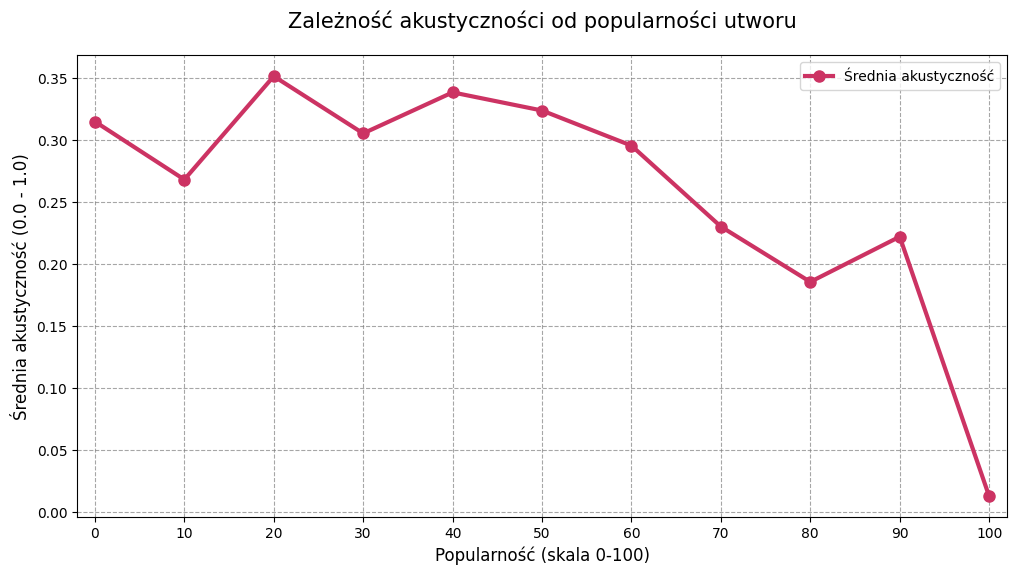

In [ ]:
# gca() - Get Current Axes, pozwala nam na bezpośrednią manipulację aktualnym układem współrzędnych (Axes)
# xaxis.grid() i yaxis.grid() - umożliwiają dodanie siatki do wykresu, co poprawia czytelność, zwłaszcza przy analizie trendów na osi czasu

df['pop_bin'] = (df['popularity'] // 10) * 10
trend_data = df.groupby('pop_bin')['acousticness'].mean()

plt.figure(figsize=(12, 6))
plt.plot(trend_data.index, trend_data.values,
         color='#CC3363',
         linewidth=3,
         marker='o',
         markersize=8,
         label='Średnia akustyczność')

ax = plt.gca()

ax.xaxis.grid(True, linestyle='--', alpha=0.7, color='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='gray')

plt.title('Zależność akustyczności od popularności utworu', fontsize=15, pad=20)
plt.xlabel('Popularność (skala 0-100)', fontsize=12)
plt.ylabel('Średnia akustyczność (0.0 - 1.0)', fontsize=12)

plt.xticks(range(0, 101, 10))

plt.xlim(-2, 102)
plt.legend()
plt.show()

##### ⭐ Zadanie 11:

Przygotuj na jednym obiekcie `axes` wykres liniowy (`plot`) i wykres kolumnowy (`bar`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zapoznaj się z parametrami `color`, `marker`, `markersize`, `linestyle` i `linewidth` oraz dobierz dla nich niestandardowe wartości. Zadbaj o czytelność wykresu (tytuł wykresu i podpisy osi).

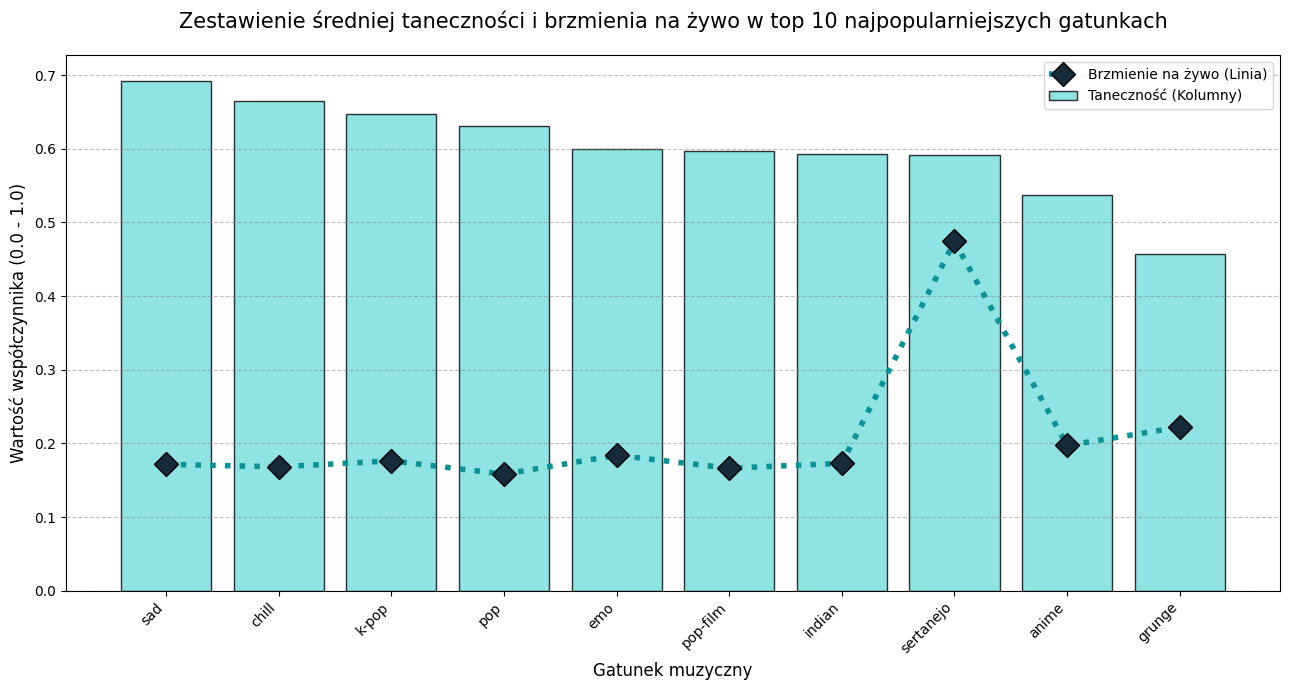

In [ ]:
COLOR_BAR = "#75DDDD"
COLOR_LINE = "#0a9396"
COLOR_MARKER = "#172A3A"

top_genres = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10).index
trend_data = df[df['track_genre'].isin(top_genres)].groupby('track_genre')[['danceability', 'liveness']].mean()

trend_data = trend_data.sort_values(by='danceability', ascending=False)

genres = trend_data.index
dance = trend_data['danceability'].values
valence = trend_data['liveness'].values

plt.figure(figsize=(13, 7))

ax = plt.gca()

# 4. Rysowanie Bar na obiekcie ax
ax.bar(genres, dance, color=COLOR_BAR, edgecolor='black', alpha=0.8, label='Taneczność (Kolumny)')

# 5. Rysowanie Plot
ax.plot(genres, valence,
        color=COLOR_LINE,
        linestyle=':',           # linia kropkowana
        linewidth=4,             # gruba linia
        marker='D',              # Diament
        markersize=12,           # duży rozmiar markera
        markerfacecolor=COLOR_MARKER,
        markeredgecolor='black', # Czarne obramowanie markera
        label='Brzmienie na żywo (Linia)')

ax.set_title('Zestawienie średniej taneczności i brzmienia na żywo w top 10 najpopularniejszych gatunkach', fontsize=15, pad=20)
ax.set_xlabel('Gatunek muzyczny', fontsize=12)
ax.set_ylabel('Wartość współczynnika (0.0 - 1.0)', fontsize=12)

plt.xticks(rotation=45, ha='right')

ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

##### ⭐ Zadanie 12:

Przedstaw na jednym obiekcie `axes` wykres liniowy (`plot`) i wykres zamalowujący przestrzeń pomiędzy dwoma horyzontalnymi krzywymi (`fill_between`). Wykorzystaj dane, które sam wybierzesz w sensowny sposób. Na pierwszym wykresie przedstaw średnią wartość, a na drugim wykresie pokaż minimum i maksimum. Zadbaj o czytelność wykresu (tytuł wykresu i podpisy osi).

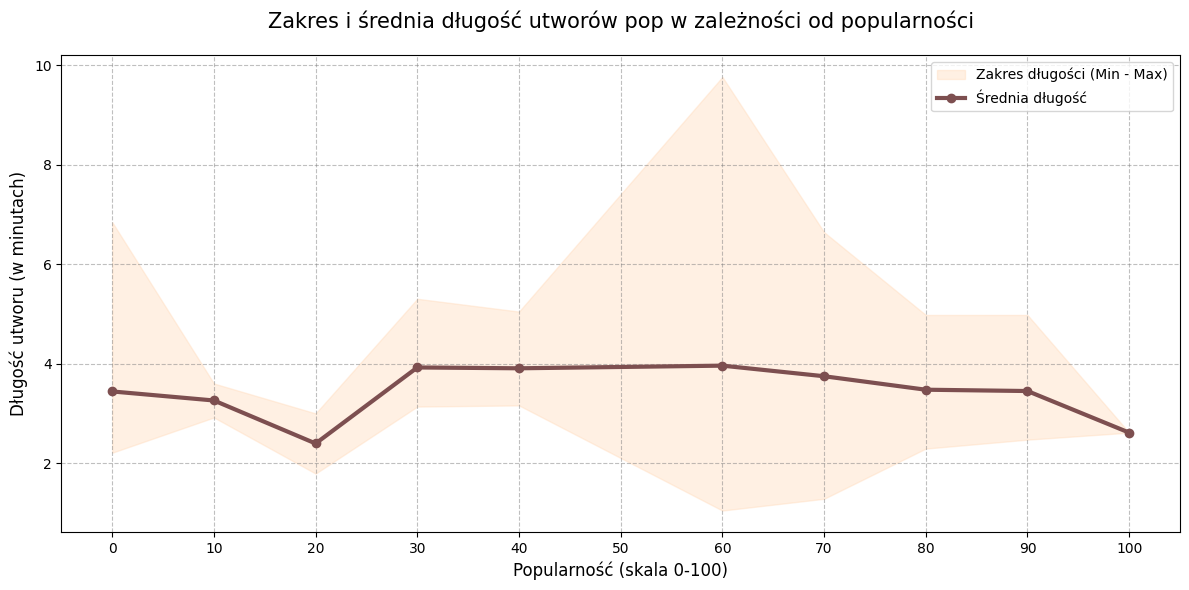

In [ ]:
# axes - Obszar podwykresu (układ współrzędnych) wewnątrz obiektu figure. To tutaj faktycznie rysowane są dane, osie, tytuły i legendy.
# fill_between - funkcja wypełniająca obszar między dwiema liniami, tworząc efekt wizualnej "wstęgi" pokazującej zakres zmienności danych.
COLOR_LINE = "#7d4f50"
COLOR_FILL = "#ffdab9"

df_pop = df[df['track_genre'] == 'pop'].copy()
df_pop['duration_min'] = df_pop['duration_ms'] / 60000

df_pop['pop_bin'] = (df_pop['popularity'] // 10) * 10
stats = df_pop.groupby('pop_bin', observed=False)['duration_min'].agg(['mean', 'min', 'max'])

plt.figure(figsize=(12, 6))
ax = plt.gca()

ax.fill_between(stats.index, stats['min'], stats['max'],
                color=COLOR_FILL, alpha=0.4, label='Zakres długości (Min - Max)')

ax.plot(stats.index, stats['mean'],
        color=COLOR_LINE, linewidth=3, marker='o', markersize=6,
        label='Średnia długość')

ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.margins(x=0.05)

plt.title('Zakres i średnia długość utworów pop w zależności od popularności', fontsize=15, pad=20)
plt.xlabel('Popularność (skala 0-100)', fontsize=12)
plt.ylabel('Długość utworu (w minutach)', fontsize=12)

plt.xticks(range(0, 101, 10))
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

--------------------
### Wykres bąbelkowy i punktowy

Wykres bąbelkowy rozszerza wykres punktowy o trzecią wartość dla danej serii danych, która jest prezentowana za pomocą rozmiaru znacznika. Przy rosnącej
liczbie zależności, konieczne jest umieszczenie dokładnego opisu wykresu razem z legendą.

##### ⭐ Zadanie 13:

Przygotuj wykres bąbelkowy (`scatter`) opierając się na danych, które sam wybierzesz w sensowny sposób. Wykorzystaj rozmiary i kolory markerów do zaprezentowania większej liczby informacji. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi i opis skali koloru).

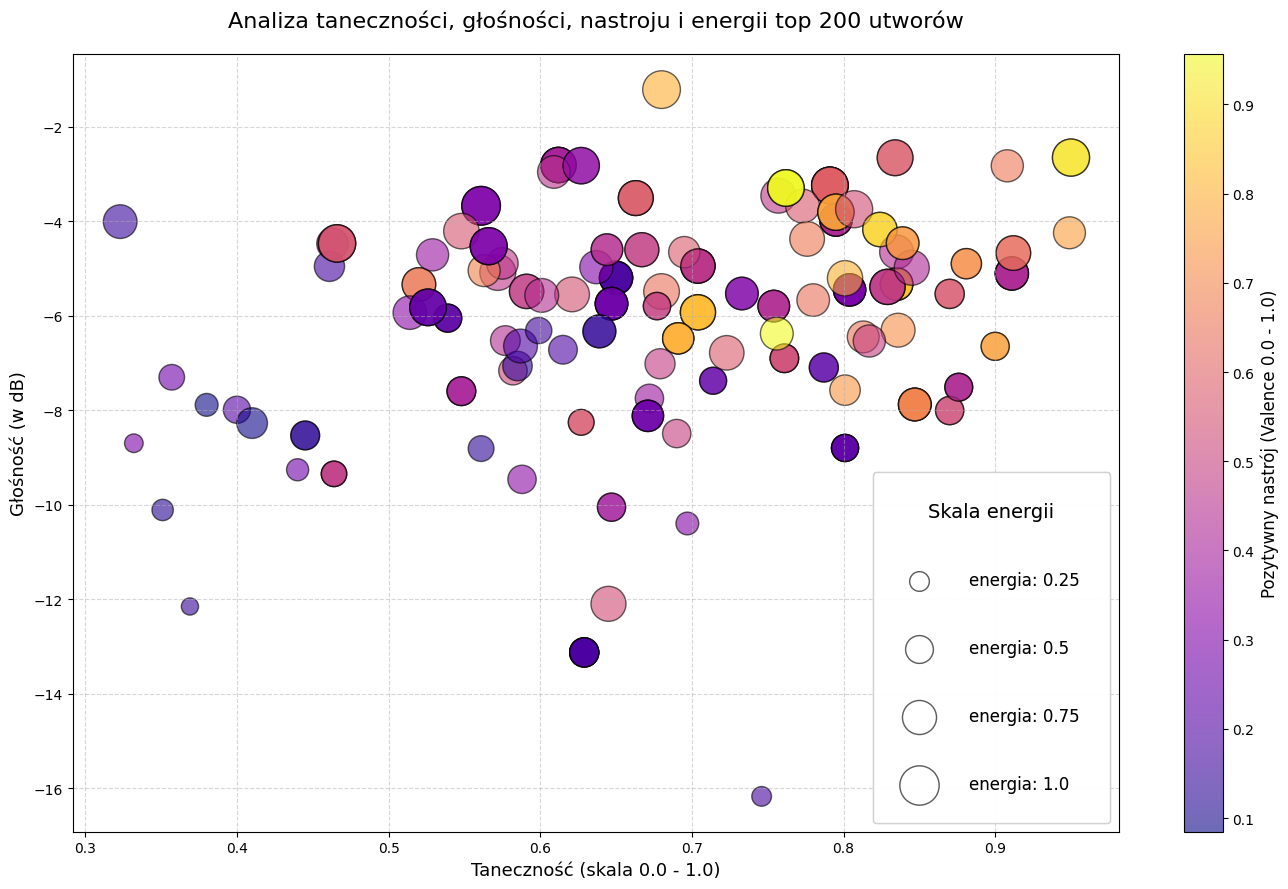

In [ ]:
top_200 = df.sort_values(by='popularity', ascending=False).head(200)

x = top_200['danceability'].values
y = top_200['loudness'].values
colors = top_200['valence'].values
energy = top_200['energy'].values
scale = 800 # Skala bąbla
sizes = energy * scale

plt.figure(figsize=(14, 9))
ax = plt.gca()

scatter = ax.scatter(x, y, s=sizes, c=colors, alpha=0.6,
                     cmap='plasma', edgecolors='black')

for e_val in [0.25, 0.50, 0.75, 1.0]:
    ax.scatter([], [], s=e_val * scale, c='white', edgecolors='black',
               alpha=0.6, label=f'energia: {e_val}')

legend_size = ax.legend(labelspacing=3.0,
                        title="Skala energii",
                        loc='lower right',
                        frameon=True,
                        fontsize=12,
                        title_fontsize=14,
                        borderpad=1.8,
                        handletextpad=2.0)
ax.add_artist(legend_size)

colorbar = plt.colorbar(scatter)
colorbar.set_label('Pozytywny nastrój (Valence 0.0 - 1.0)', fontsize=12)

ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.title('Analiza taneczności, głośności, nastroju i energii top 200 utworów',
          fontsize=16, pad=20)
plt.xlabel('Taneczność (skala 0.0 - 1.0)', fontsize=13)
plt.ylabel('Głośność (w dB)', fontsize=13)

plt.tight_layout()
plt.show()

##### ⭐ Zadanie 14:

Czy wszystkie informacje z zadania 13 można przedstawić za pomocą wykresu punktowego stworzonego jako wykres liniowy (`plot`) bez linii? Jeżeli tak, wykonaj taki wykres. Jeżeli nie, zdecyduj, które dane są najmniej istotne i zrezygnuj z nich przy wykonywaniu takiego wykresu. Zadbaj o czytelność wykresu (tytuł wykresu i podpisy osi). Do swojego rozwiązania dodaj dowolną animację.

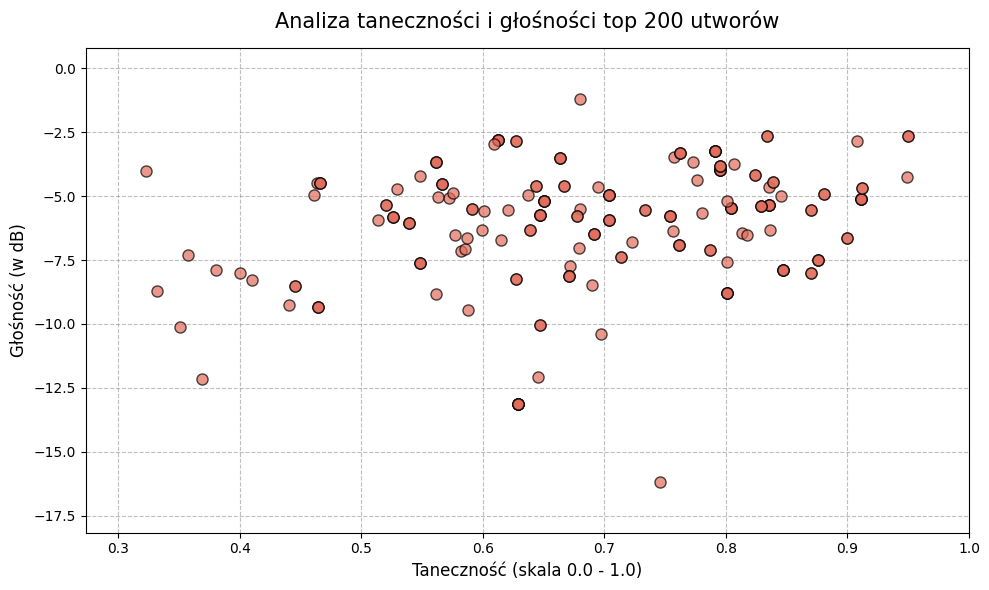

In [ ]:
# w plot nie można umieścić trzeciego wymiaru w postaci rozmiaru bąbelków, oraz czwartego wymiaru w postaci mapy kolorów.

top_200 = df.sort_values(by='popularity', ascending=False).head(200)

x = top_200['danceability'].values
y = top_200['loudness'].values

MAIN_COLOR = "#e26d5c"

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_xlim(x.min() - 0.05, x.max() + 0.05)
ax.set_ylim(y.min() - 2, y.max() + 2)

line, = ax.plot([], [], linestyle='none', marker='o',
                color=MAIN_COLOR, markersize=8, markeredgecolor='black', alpha=0.7)

ax.set_title('Analiza taneczności i głośności top 200 utworów', fontsize=15, pad=15)
ax.set_xlabel('Taneczność (skala 0.0 - 1.0)', fontsize=12)
ax.set_ylabel('Głośność (w dB)', fontsize=12)
ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')

def animate(i):
    line.set_data(x[:i], y[:i])
    return line,

ani = animation.FuncAnimation(fig, animate, frames=len(x)+1, interval=50, blit=True)

ani.save('spotify_animacja.gif', writer='pillow')

plt.tight_layout()
plt.show()

-------------------
### Mapa ciepła

Mapa ciepła to wizualizacja wielowymiarowa, która wykorzystywana jest do znajdowania wzorców w danych. Dwie kategorie danych umieszczone są w wierszach i kolumnach. Wartości zawarte w macierzy są reprezentowane przez kolory lub nasycenie kolorów, dzięki czemu jawnie odzwierciedlają zależności pomiędzy kategoriami.

##### ⭐ Zadanie 15:

Przygotuj mapę ciepła (`imshow`, `pcolormesh`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zapoznaj się z dwiema metodami rysowania map ciepła i zdecyduj, która będzie lepsza w twoim rozwiązaniu. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi i opis skali koloru).

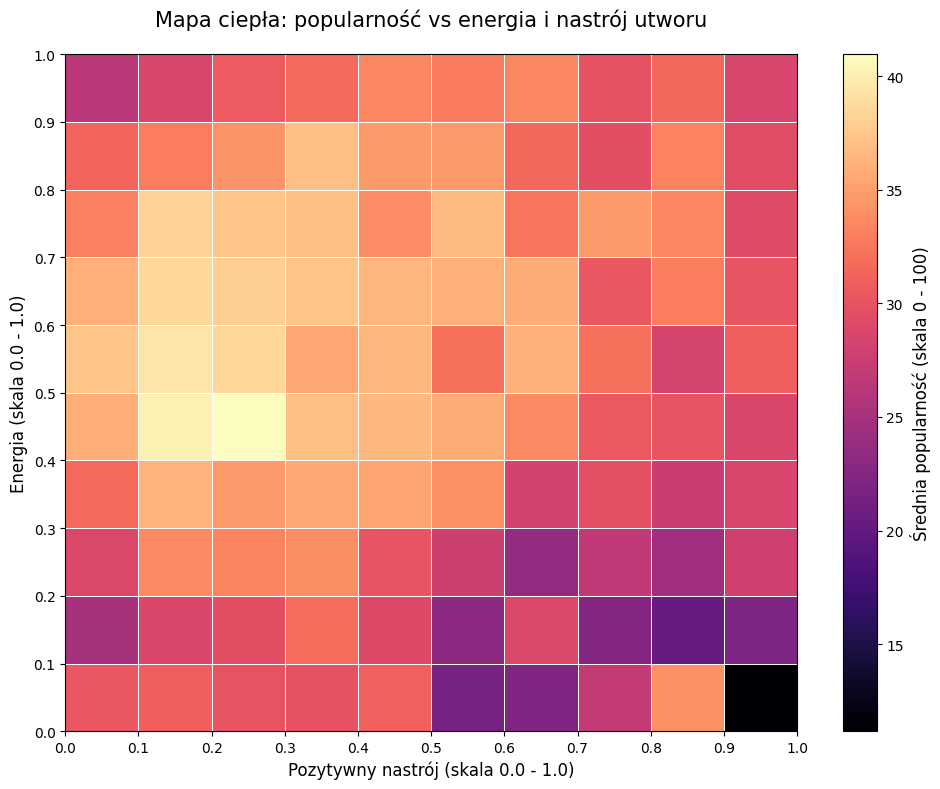

In [ ]:

bins = np.arange(0, 1.1, 0.1)

df['energy_bin'] = pd.cut(df['energy'], bins=bins)
df['valence_bin'] = pd.cut(df['valence'], bins=bins)

heatmap_data = df.groupby(['energy_bin', 'valence_bin'], observed=False)['popularity'].mean().unstack()

X, Y = np.meshgrid(bins, bins)

Z = heatmap_data.fillna(0).values

plt.figure(figsize=(10, 8))
ax = plt.gca()

heatmap = ax.pcolormesh(X, Y, Z, cmap='magma', edgecolors='white', linewidth=0.5)

colorbar = plt.colorbar(heatmap)
colorbar.set_label('Średnia popularność (skala 0 - 100)', fontsize=12)

ax.set_title('Mapa ciepła: popularność vs energia i nastrój utworu', fontsize=15, pad=20)
ax.set_xlabel('Pozytywny nastrój (skala 0.0 - 1.0)', fontsize=12)
ax.set_ylabel('Energia (skala 0.0 - 1.0)', fontsize=12)

ax.set_xticks(bins)
ax.set_yticks(bins)

plt.tight_layout()
plt.show()

-------------------
### Wykres radarowy

Wykres radarowy przedstawia wiele zmiennych o tej samej skali w formie pojedynczego wielokąta zamkniętego umieszczonego na okręgu. Wierzchołki figury są ułożone zgodnie z wartościami dla kolejnych kategorii.

##### ⭐ Zadanie 16:

Przygotuj wykres radarowy (`polar`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zadbaj o czytelność wykresu (tytuł wykresu i podpisy osi).

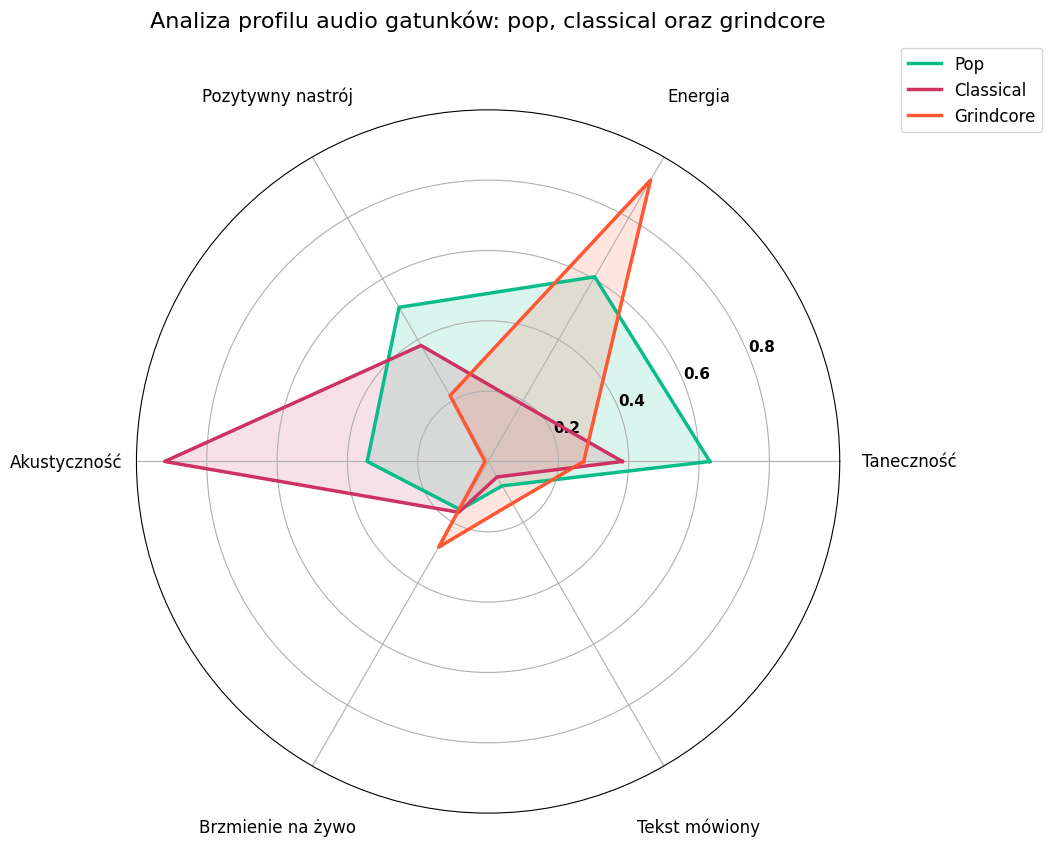

In [ ]:
COLOR_POP = "#09BC8A"
COLOR_CLASSICAL = "#CC3363"
COLOR_GRINDCORE = "#FF5733"

features = ['danceability', 'energy', 'valence', 'acousticness', 'liveness', 'speechiness']

def get_genre_data(genre_name):
    data = df[df['track_genre'] == genre_name][features].mean().values
    return np.concatenate((data, [data[0]]))

pop_data = get_genre_data('pop')
classical_data = get_genre_data('classical')
grindcore_data = get_genre_data('grindcore')

angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

plt.figure(figsize=(11, 11))
ax = plt.subplot(111, polar=True)

# POP
ax.plot(angles, pop_data, color=COLOR_POP, linewidth=2.5, label='Pop')
ax.fill(angles, pop_data, color=COLOR_POP, alpha=0.15)

# CLASSICAL
ax.plot(angles, classical_data, color=COLOR_CLASSICAL, linewidth=2.5, label='Classical')
ax.fill(angles, classical_data, color=COLOR_CLASSICAL, alpha=0.15)

# GRINDCORE
ax.plot(angles, grindcore_data, color=COLOR_GRINDCORE, linewidth=2.5, label='Grindcore')
ax.fill(angles, grindcore_data, color=COLOR_GRINDCORE, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(['Taneczność', 'Energia', 'Pozytywny nastrój',
                    'Akustyczność', 'Brzmienie na żywo', 'Tekst mówiony'], fontsize=12)

ax.tick_params(axis='x', pad=40)

ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8'], color="black", fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.0)

plt.title('Analiza profilu audio gatunków: pop, classical oraz grindcore',
          fontsize=16, pad=60)

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12, frameon=True)

plt.tight_layout()
plt.show()